# Community detection using iQ-Xtreme

**Inspiration-Q**


---

Many real-life structures can be adequately modeled by means of a complex network, where the nodes may correspond to entities, people or companies, while the edges encode relationships among them. A general problem arises when we try to segment the graph into different clusters, which gives us useful information about the graph structure. Community detection, first proposed by [Girvan and Newman](https://www.pnas.org/doi/10.1073/pnas.122653799), is a graph partitioning method in which nodes are separated into different communities, where nodes within any of these communities are highly connected (high intra-connectivity), while nodes in different communities are less connected (low inter-connectivity).

In this notebook we shall perform graph parititoning into k clusters based on modularity.

---


## Content

1. Community detection for two communities:

    * Generating a benchmark graph.

    * QUBO formulation of the problem

    * Solving the QUBO with iQ-Xtreme

    * Visualizing solution

2. Community detection for K communities:

    * QUBO formulation of the problem

    * Solving the QUBO problem with iQ-Xtreme

    * Decoding the solution array

    * Visualizing solution


## Installing and Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
import networkx.algorithms.community as nx_comm

import iq.api.iqrestapi
import iq.optim.qubo
import iq.optim.quco

In [2]:
iq.api.iqrestapi.initialize_credentials("YOUR_API_KEY")

## 1. Community detection for two communities

### Generating a benchmark graph

We will use Zachary’s Karate Club graph as an example, which can be loaded directly from NetworKx

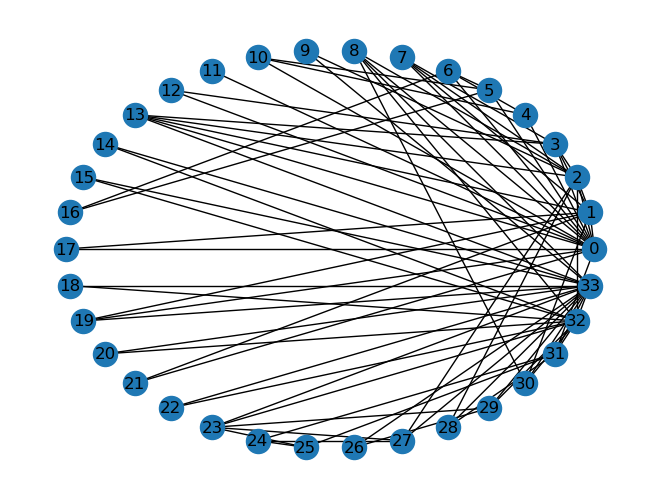

In [3]:
G = nx.karate_club_graph()
nx.draw_circular(G, with_labels=True)
plt.show()

### QUBO formulation of the problem

To quantify the quality of a graph partitioning into different communities, the modularity metric $M$ compares the connectivity within communities with respect to the connectivity of a random network in which the expected degree of each node matches the degree of the node in the original graph.

Let us define the following quantities

* $A$ - Adjacency matrix of the unweighted graph (1 if nodes $i$ and $j$ are connected, 0 - otherwise.)

* $g_i = ∑_j A_{ij}$ - is the sum of weights departing from node $i$.

* $m=\frac{1}{2}∑_i g_i$ - is the total sum of weights.


We can define the modularity $M$ as the difference between the actual weight $A_{ij}$ and the expected weight in the benchmark random graph: $\frac{g_i\cdot g_j}{2m}$. We can call that $B$.

$$B = A_{ij}-\frac{g_i\cdot g_j}{2m}$$

Modularity is then be defined as:

$$M = \frac{1}{2m} \sum_{i,j}(A_{ij}-\frac{g_i\cdot g_j}{2m})\delta(c_i,c_j)$$

where the Kronecker-delta $δ(c_i , c_j )$ (1 if node $i$ and node $j$ are in the same community and 0 otherwise).

Our goal is to maximize the modularity $M$ by finding a proper community assignment $c_i$ for each node in the graph. In the case of two communities, the problem is already expressed in terms of Quadratic Unconstrained Binary Optimization QUBO) problem, where the QUBO matrix is simply:

$$Q = -\frac{1}{m}B,$$

and the optimization problem comes down to

$$\min_{\mathbf x} \mathbf x^TQ\mathbf x$$

with $x_j\in\{0,1\}$ being a vector of decision variables.

In [4]:
def cost_from_graph(G):
    # Adjacency Matrix
    A = np.array(nx.to_numpy_array(G))
    size = A.shape[0]

    # the sum of weights departing from node i
    g = []
    for i in range(size):
        sum = 0
        for j in range(size):
            sum += A[i][j]
        g.append(sum)

    # m - the total sum of weights
    sum_g = 0
    for i in g:
        sum_g += i
    m = sum_g / 2

    # B matrix

    B = np.zeros([size, size])
    for i in range(size):
        for j in range(size):
            B[i, j] = A[i, j] - g[i] * g[j] / (2 * m)

    # The QUBO matrix
    Q = -B / (2*m)
    return Q

In [5]:
Q = cost_from_graph(G)

### Solving the QUBO problem with iQ-Xtreme

In [6]:
x, cost = iq.optim.qubo.solve_QUBO(Q, shots=10, steps=2000)

In [7]:
def modularity_communities(G, solution):

    size = G.number_of_nodes()
    # Adjacency Matrix
    A = np.array(nx.to_numpy_array(G))

    # the sum of weights departing from node i
    g = []
    for i in range(size):
        sum = 0
        for j in range(size):
            sum += A[i][j]
        g.append(sum)

    # m - the total sum of weights
    sum_g = 0
    for i in g:
        sum_g += i
    m = sum_g / 2
    mod = 0.0
    for i in range(size):
        for j in range(size):
            if solution[i] == solution[j]:
                mod += A[i, j] - g[i] * g[j] / (2 * m)
    mod = mod / (2 * m)
    return mod

In [8]:
modularity_communities(G, x)

np.float64(0.40362811791383263)

### Visualising the solution

In [9]:
def drawSolution(G, x, k, font_color="white"):
    communities = []
    for i in range(k):
        communities.append([])
    for index, value in enumerate(x):
        communities[value].append(index)

    class_map = {}
    for cl in range(len(communities)):
        for n in communities[cl]:
            class_map.update({n: cl})

    class_map = dict(sorted(class_map.items()))

    pos = nx.spring_layout(G, seed=7)
    nx.draw(
        G,
        cmap=plt.get_cmap("Dark2"),
        pos=pos,
        node_color=list(class_map.values()),
        with_labels=True,
        font_color=font_color,
        node_size=500,
        font_size=10,
    )

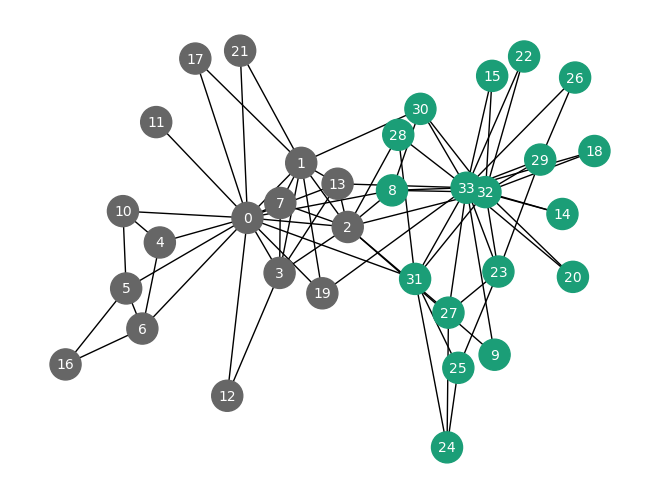

In [10]:
k = 2
drawSolution(G, x, k)  # Annealer

Calculating modularity of our solution using NetworkX

In [11]:
communities = [[] for _ in range(k)]
for i in range(len(x)):
    communities[x[i]].append(i)
nx_comm.modularity(G, communities, weight="weight", resolution=1)

0.40362811791383213

## 2. Community detection for K communities

### QUBO formulation of the problem

For the case of having $K$ communities with $K>2$, the previous decision variables $x_i$ are not enough to capture the whole set of possibilities. We generalize $x_i$ to categorical variables $x_{i,c}$, for which $x_{i,c}=1$ if node
$i$ belongs to community $c$, and $x_{i,c}=0$ otherwise (one-hot encoding).

Following the idea of [Ushijima-Mwesigwa et al.](https://dl.acm.org/doi/pdf/10.1145/3149526.3149531), we introduce a generalized modularity matrix, $Q_c$, of size $kN \times kN$ and block-diagonal form with copies of matrix $Q$ along the diagonal. Each block will now correspond to each of the $K$ communities, so that $x_{i,c}=1$ only when node $i$ is assigned to block $c$ (and 0 otherwise).

For example if $Q$ =

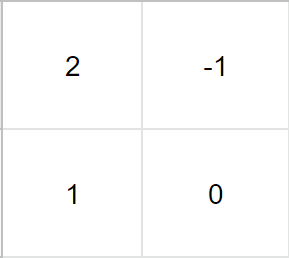

then for $K = 3$,

$Q_c=$

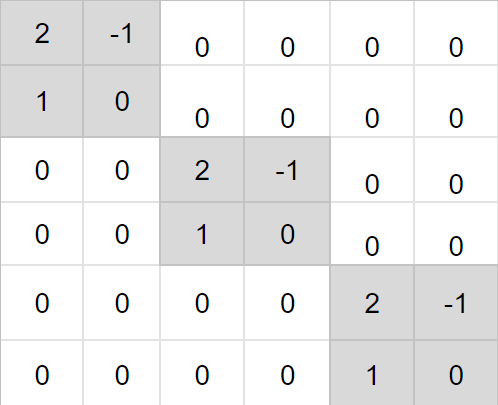

We also have to introduce a constraint on the categorical variables $x_{i,c}$ to account for the one-hot encoding.

$$Q_p = P\cdot \sum_{i=1}^N(\sum_{c=1}^K x_{i,c} -1)^2$$

* $N$ - graph size.

* $P$ -  penaltty parameter.

* $K$ - number of comunities.

Let us re-arange our categorical variables in the form of a binary decision bector of size $kN$, $x = ( x_{1,1} , x_{2,1} , … , x_{N,1} , … , x_{N,k} ) = ( x_1 , x_2 , … , x_N , … , x_{kN} )$. The penalty term can be rewritten as:

$$Q_p = P(Vx-b)^T(Vx-b)$$


where $b$ is a vector of all ones and $V = [I_N, … , I_N]$ is a matrix of size $N \times kN$ with $N \times N$ identity matrices stacked horizontally next to each other. We can further develop the penalty term in QUBO form as follows,

$$Q_p = P(V^T V – 2 diag(V^T b))$$

Our final QUBO matrix will then be:

$$Q_t=Q_c + Q_p$$

### Solving with the QUCO solver

The iQ-Xtreme SDK provides a dedicated QUCO (Quadratic Unconstrained Category
Optimization) solver that handles the one-hot encoding, penalty terms, and
solution decoding internally. We only need to pass the original modularity
QUBO matrix Q and the number of communities k.

In [12]:
k = 3
community_array, cost = iq.optim.quco.solve_QUCO(Q, k=k, shots=20)
community_array = np.asarray(community_array)
community_array

array([0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 0, 0, 2, 2, 1, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

With this information, we can calculate the modularity of the solution by using our previously defined funcion

In [13]:
print("Modularity of solution:", modularity_communities(G, community_array))

Modularity of solution: 0.43452146698899996


But we can calculate modularity of our solution using NetworkX buil-in functions

In [14]:
communities = [[] for _ in range(k)]
for i in range(len(community_array)):
    communities[community_array[i]].append(i)
print(
    "Modularity with NetworKx:", nx_comm.modularity(G, communities, weight="weight", resolution=1)
)

Modularity with NetworKx: 0.4345214669889994


### Visualizing the solution

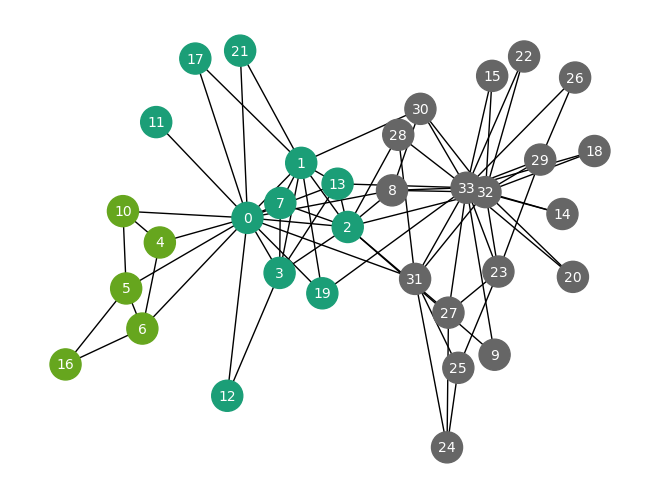

In [15]:
drawSolution(G, community_array, k)

## 3. Larger example: Les Miserables co-appearance network

The Les Miserables graph is a weighted network of 77 characters from Victor
Hugo's novel, where edge weights represent the number of co-appearances in the
same chapter. It is a classic benchmark for community detection algorithms
(see [Negre et al., 2020](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0227538)
and the [AWS community detection blog post](https://aws.amazon.com/blogs/quantum-computing/community-detection-using-hybrid-quantum-annealing-on-amazon-braket-part-2/)).

Les Miserables graph: 77 nodes, 254 edges


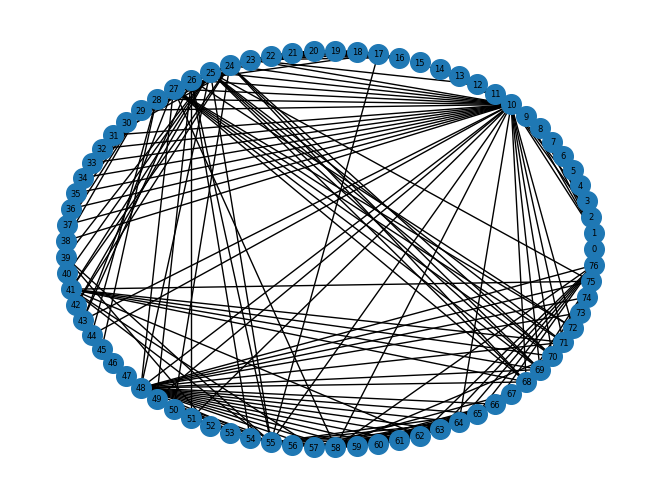

In [16]:
G_lm = nx.convert_node_labels_to_integers(nx.les_miserables_graph())
print(f"Les Miserables graph: {G_lm.number_of_nodes()} nodes, {G_lm.number_of_edges()} edges")
nx.draw_circular(G_lm, with_labels=True, font_size=6, node_size=200)
plt.show()

### Building the modularity matrix

In [17]:
Q_lm = cost_from_graph(G_lm)

### Community detection with k=2 (QUBO)

In [18]:
x_lm, cost_lm = iq.optim.qubo.solve_QUBO(Q_lm, shots=10, steps=2000)
print(f"QUBO cost: {cost_lm:.4f}")

QUBO cost: -0.2007


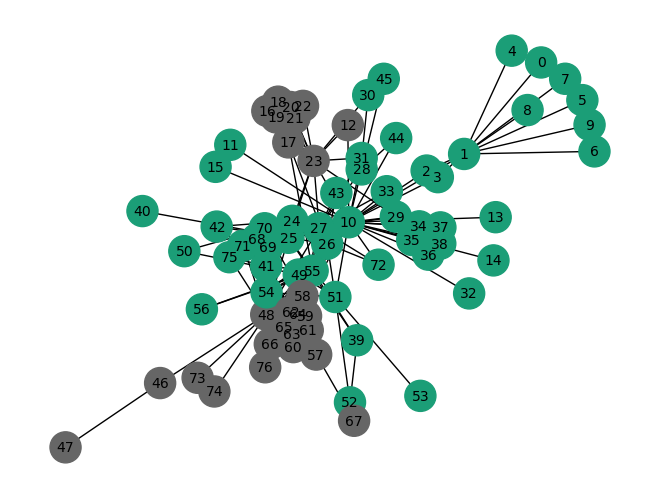

In [19]:
k_lm = 2
drawSolution(G_lm, x_lm, k_lm, font_color="black")

In [20]:
communities_lm = [[] for _ in range(k_lm)]
for i in range(len(x_lm)):
    communities_lm[x_lm[i]].append(i)
print(
    "Modularity with NetworkX:",
    nx_comm.modularity(G_lm, communities_lm, weight="weight", resolution=1),
)

Modularity with NetworkX: 0.4014753123140987


### Community detection with k=6 (QUCO)

The Les Miserables network has richer structure than two communities.
We use the QUCO solver to partition the graph into 6 communities directly.

In [21]:
k_lm = 6
community_array_lm, cost_lm = iq.optim.quco.solve_QUCO(Q_lm, k=k_lm, shots=100)
community_array_lm = np.asarray(community_array_lm)
print(f"QUCO cost: {cost_lm:.4f}")

QUCO cost: -0.5667


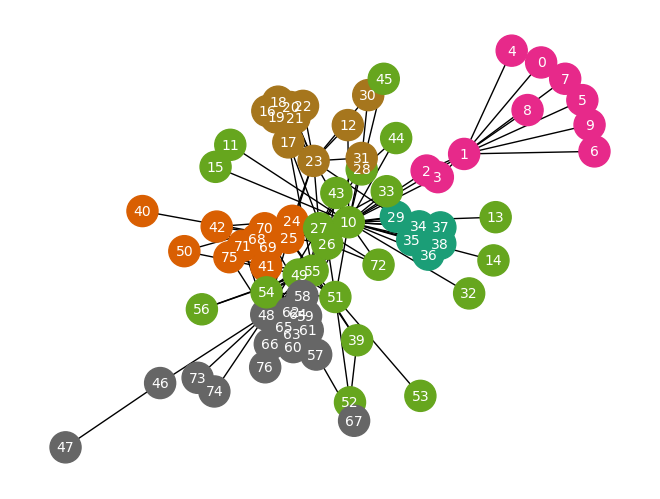

In [22]:
drawSolution(G_lm, community_array_lm, k_lm)

In [23]:
communities_lm = [[] for _ in range(k_lm)]
for i in range(len(community_array_lm)):
    communities_lm[community_array_lm[i]].append(i)
print(
    "Modularity with NetworkX:",
    nx_comm.modularity(G_lm, communities_lm, weight="weight", resolution=1),
)

Modularity with NetworkX: 0.566687983343248
